# Uniform Distribution

# Superposition Explorer: Uniform Distribution
**Objective:** Understand state distribution across a multi-qubit system.

**Theory:**
Applying a Hadamard ($H$) gate to a single qubit puts it in a 50/50 superposition. If we apply an $H$ gate to $n$ qubits, the system enters a **uniform superposition** of all $2^n$ possible states. 

For example, with 3 qubits, there are $2^3 = 8$ possible states (`000`, `001`, `010`, etc.). Because the superposition is uniform, each state has an equal probability of being measured (roughly 12.5%).

In [14]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler # Modern V2 execution primitive
from qiskit.visualization import plot_histogram
from IPython.display import display

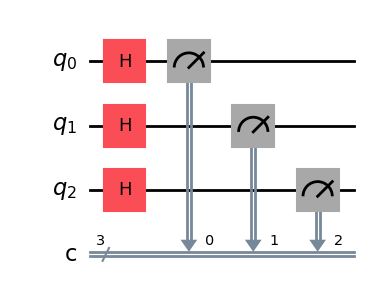

In [15]:
n_qubits = 3

# Initialize circuit with n qubits and n classical bits
qc = QuantumCircuit(n_qubits, n_qubits)

# Apply H-gates to all qubits to create the uniform superposition
for qubit in range(n_qubits):
    qc.h(qubit)

# Measure all qubits
qc.measure(range(n_qubits), range(n_qubits))

# Draw the circuit
display(qc.draw('mpl'))

Raw Counts: {'000': 126, '011': 123, '100': 126, '110': 144, '001': 137, '010': 123, '101': 117, '111': 128}


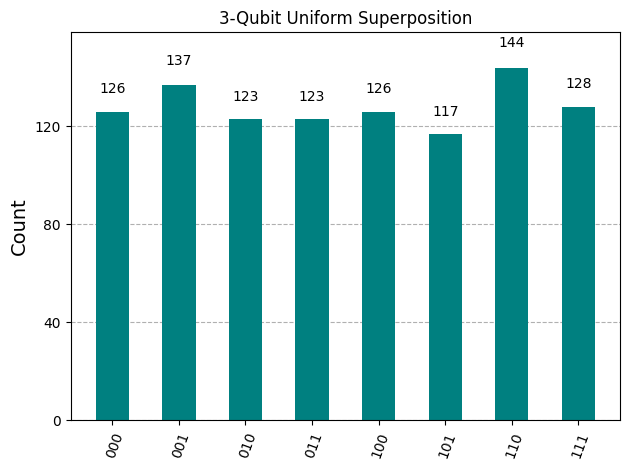

In [16]:
# Initialize the V2 Sampler
sampler = StatevectorSampler()

# Execute the circuit over 1024 shots
job = sampler.run([qc], shots=1024)
result = job.result()[0]

# Extract counts from the classical register 'c'
counts = result.data.c.get_counts()

print(f"Raw Counts: {counts}")

# Plot the histogram. You should see 8 bars, all roughly equal height.
display(plot_histogram(counts, title="3-Qubit Uniform Superposition", color='teal'))